# Anonymisation des données

Objectif : repérer les données qui identifient une personne dans les quatre sources, et vérifier que l'anonymisation les retire.

Deux usages rendent ce travail nécessaire :

- **la publication du dataset et l'entraînement** : le dataset est publié sur Hugging Face et sert à entraîner le modèle. Les quatre sources sont concernées ;
- **l'annotation des cas de triage** par un LLM externe (Mistral Large) : les cas de MediQAl et d'UltraMedical quittent notre machine. Ils doivent être anonymisés (MediQAl) ou filtrés (UltraMedical) avant l'envoi.

Plan : les données, ce qu'on cherche, pourquoi Presidio tel quel ne convient pas, les identifiants directs, les noms de patients source par source, les dates, le contrôle sur le dataset produit, la stratégie de masquage, puis la synthèse avec la justification RGPD.

In [1]:
import random
import re
import sys
import time
import warnings
from collections import Counter, defaultdict

sys.path.append("..")
# tqdm signale qu'ipywidgets manque (barres de progression) : sans effet sur les calculs
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from dotenv import load_dotenv
from presidio_analyzer import AnalyzerEngine
from presidio_analyzer.nlp_engine import NlpEngineProvider
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig, RecognizerResult

from scripts.cases import is_triage_case
from scripts.extraction import (
    ORIGINES_ULTRAMEDICAL_ECARTEES, REVISIONS, build_dpo_dataset, build_sft_dataset,
    clean_sft_dataset, load_frenchmedmcqa, load_mediqa, load_mediqal_cases, load_medquad,
)
from scripts.patient_names import PATIENT_NAME_RULES, find_leftover_names, replace_patient_names
from src.visualizer import create_heatmap, save_figure

_ = load_dotenv()

## Les données

Pour chaque source, on regarde les textes qui seront publiés ou envoyés à Mistral :

- **MediQAl** : les cas cliniques des trois configs, plus les questions et réponses de `oeq`. Des configs QCM, on ne garde que les cas ;
- **FrenchMedMCQA** : chaque question avec ses cinq propositions ;
- **MedQuAD** : chaque question avec sa réponse ;
- **UltraMedical-Preference** : chaque prompt avec ses réponses chosen et rejected.

Les versions des datasets sont fixées dans `REVISIONS` (`scripts/extraction.py`), les mêmes que pour la construction du dataset.

In [2]:
mediqal = {
    config: load_dataset("ANR-MALADES/MediQAl", config, revision=REVISIONS["ANR-MALADES/MediQAl"])
    for config in ["oeq", "mcqm", "mcqu"]
}
frenchmedmcqa = load_dataset("nthngdy/frenchmedmcqa", revision=REVISIONS["nthngdy/frenchmedmcqa"])
medquad = load_dataset("keivalya/MedQuad-MedicalQnADataset", revision=REVISIONS["keivalya/MedQuad-MedicalQnADataset"])
ultramedical = load_dataset("TsinghuaC3I/UltraMedical-Preference", revision=REVISIONS["TsinghuaC3I/UltraMedical-Preference"])

# Textes qui seront publiés ou envoyés à Mistral, source par source
mediqal_cases = sorted({
    case for dataset in mediqal.values() for split_data in dataset.values()
    for case in split_data["clinical_case"] if case
})
oeq = mediqal["oeq"]["test"]
source_texts = {
    "mediqal": mediqal_cases + list(oeq["question"]) + list(oeq["answer"]),
    "frenchmedmcqa": [
        "\n".join([ex["question"]] + [ex[f"answer_{letter}"] for letter in "abcde"])
        for split_data in frenchmedmcqa.values() for ex in split_data
    ],
    "medquad": [q + "\n" + a for split_data in medquad.values() for q, a in zip(split_data["Question"], split_data["Answer"])],
    "ultramedical": [
        prompt + "\n" + chosen[-1]["content"] + "\n" + rejected[-1]["content"]
        for split_data in ultramedical.values()
        for prompt, chosen, rejected in zip(split_data["prompt"], split_data["chosen"], split_data["rejected"])
    ],
}
# Origine de chaque texte UltraMedical (le dataset d'où vient le prompt : ChatDoctor, MedMCQA...)
ultramedical_origin = {}
for split_data in ultramedical.values():
    for prompt, chosen, rejected, prompt_id in zip(split_data["prompt"], split_data["chosen"], split_data["rejected"], split_data["prompt_id"]):
        origin = prompt_id.split(",")[0]
        ultramedical_origin[prompt] = origin
        ultramedical_origin[prompt + "\n" + chosen[-1]["content"] + "\n" + rejected[-1]["content"]] = origin
# MediQAl sans doublons : certaines questions oeq reviennent à l'identique
mediqal_texts = sorted(set(source_texts["mediqal"]))
SOURCE_LANGUAGE = {"mediqal": "fr", "frenchmedmcqa": "fr", "medquad": "en", "ultramedical": "en"}
for source, texts in source_texts.items():
    print(source, ":", len(texts), "textes")
print("mediqal sans doublons :", len(mediqal_texts), "textes")

mediqal : 13013 textes
frenchmedmcqa : 1080 textes
medquad : 16407 textes
ultramedical : 112362 textes
mediqal sans doublons : 12604 textes


## Ce qu'on cherche

Une donnée est identifiante si elle permet de retrouver une personne réelle :

- le nom d'un patient ou d'un proche (« Brigitte V. », « Monsieur Durand ») ;
- un identifiant direct : numéro de sécurité sociale (NIR) ou numéro Améli, email, téléphone.

Une donnée peut aussi identifier indirectement, en se combinant à d'autres : une date précise, un lieu, un employeur.

Ne sont pas identifiants, et doivent rester dans le texte parce qu'ils servent au triage : l'âge, le sexe, les durées (« depuis 3 jours »), les constantes, les noms de maladies et les éponymes (« syndrome de Cushing »), les noms de médicaments.

## Presidio tel quel ne convient pas

Presidio (conseillé par la mission) repère les entités avec un modèle de reconnaissance des noms propres (spaCy, `fr_core_news_md` et `en_core_web_md`) et des expressions régulières. Je le lance tel quel sur 80 textes par source, tronqués à 1000 caractères.

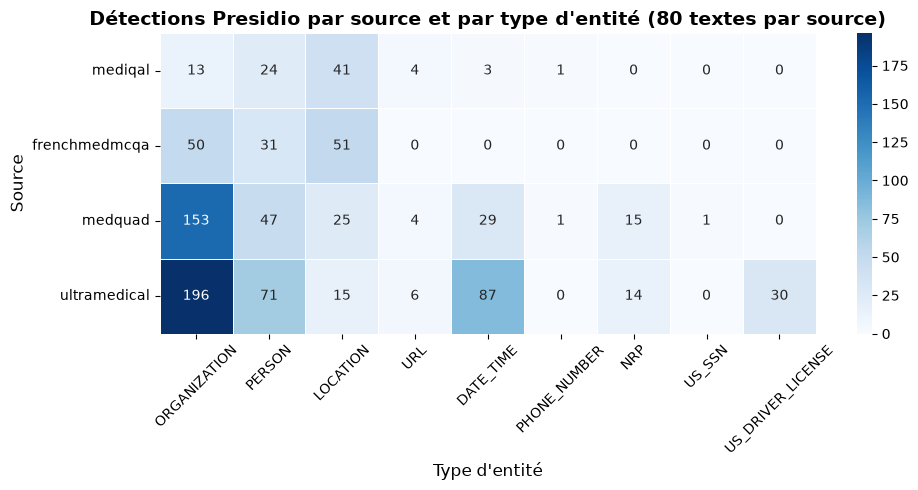

In [3]:
SPACY_MODELS = {"fr": "fr_core_news_md", "en": "en_core_web_md"}


def build_analyzer(language):
    config = {"nlp_engine_name": "spacy", "models": [{"lang_code": language, "model_name": SPACY_MODELS[language]}]}
    nlp_engine = NlpEngineProvider(nlp_configuration=config).create_engine()
    return AnalyzerEngine(nlp_engine=nlp_engine, supported_languages=[language])


analyzers = {language: build_analyzer(language) for language in ["fr", "en"]}

rng = random.Random(42)
detections = {}
examples = defaultdict(list)  # (source, type d'entité) -> entités détectées
for source, texts in source_texts.items():
    language = SOURCE_LANGUAGE[source]
    counter = Counter()
    for text in rng.sample(texts, 80):
        text = text[:1000]
        for result in analyzers[language].analyze(text=text, language=language):
            counter[result.entity_type] += 1
            examples[(source, result.entity_type)].append(text[result.start:result.end])
    detections[source] = counter

fig, ax = plt.subplots(figsize=(10, 5))
create_heatmap(
    pd.DataFrame(detections).fillna(0).T, ax, fmt=".0f", cmap="Blues",
    title="Détections Presidio par source et par type d'entité (80 textes par source)",
    xlabel="Type d'entité", ylabel="Source",
)
plt.tight_layout()
save_figure(fig, "02_anonymisation/detections_presidio")
plt.show()

Presidio détecte surtout des PERSON, LOCATION et ORGANIZATION. Voici ce qu'il y a derrière :

In [4]:
for entity_type in ["PERSON", "LOCATION", "ORGANIZATION", "NRP", "DATE_TIME", "URL", "PHONE_NUMBER", "US_DRIVER_LICENSE"]:
    for source in source_texts:
        found = examples[(source, entity_type)][:12]
        if found:
            print(f"{entity_type} ({source}) :", found)

PERSON (mediqal) : ['Madame S', 'Contexte', 'Chancre', 'Primo', 'Hémogramme :', 'Scotomes', 'ketoprofène \n', 'Me V.', 'Mademoiselle H.', 'Madame X', 'Inconvénients', 'Cédric']
PERSON (frenchmedmcqa) : ['Induction', 'La Zopiclone', 'Vibrio', 'annexine', 'Cushing', 'Erythromycine', 'H. pylori', 'H. pylori', 'H.', 'Elévation', 'Elévation', 'Bonne']
PERSON (medquad) : ['mutati', 'Aarskog-Scott', 'Aarskog-Scott', 'B.', 'Syndactyly', 'Syndactyly', 'Solitary Kidney', 'Filamin B', 'Filamin B', 'Agnosia', 'I.', 'Kawasaki']
PERSON (ultramedical) : ['A. Corticobasal', 'A. Corticobasal', 'A. Ventriculostomy', 'Leukocyte', 'A. Ibuprofen\nB. Hydroxychloroquine\nC.', 'A. Intraventricular', 'A. Intraventricular', 'Grade I.\n\nC. Hemorrhage', 'A. Transfusion', 'Prothrombin Time', 'C. Haemophilus', 'Glycoproteins']
LOCATION (mediqal) : ['Inférieur', 'Syphilis', 'Roséole', 'Polyadénopathies', 'Céphalées', 'Signes', 'Toxidermie', 'hyperkaliémie\n', 'diurèse\n', 'VD', 'VD', 'hémorroïdaire stade III']
LOCA

Presque tout est du vocabulaire médical :

- **PERSON** : dans MediQAl, quelques vrais noms de patients (« Madame S », « Mademoiselle H. », « Cédric ») noyés dans des termes médicaux (« Chancre », « Hémogramme »). Ailleurs, aucun vrai nom : des médicaments, des bactéries (« H. pylori »), des éponymes (« Kawasaki ») et des propositions de QCM (« A. Corticobasal ») ;
- **LOCATION** et **ORGANIZATION** : des termes médicaux (« Syphilis », « Foie ») et des sigles (« IRM », « SIADH »). Les rares vrais lieux sont des pays ou des régions, trop larges pour retrouver quelqu'un ;
- **NRP** : les populations où une maladie génétique est fréquente (« Ashkenazi »), une information sur un groupe, pas sur une personne ;
- **DATE_TIME** : des âges et des durées, utiles au triage ;
- **PHONE_NUMBER** et **US_DRIVER_LICENSE** : une tension artérielle (« 169/90 ») et des vertèbres (« L4 », « T11 »).

Conclusion : appliquer Presidio tel quel remplacerait du vocabulaire clinique par des balises, pour presque aucun vrai nom retiré. L'anonymisation doit être ciblée : des motifs précis pour les identifiants directs, et des règles adaptées à la façon dont chaque source nomme ses patients.

## Identifiants directs sur tout le corpus

Presidio n'a pas de reconnaissance pour le NIR français ni pour le numéro Améli (même format). J'écris le motif à la main et je vérifie d'abord qu'il trouve un vrai NIR : un résultat à zéro ne prouve rien si le motif ne trouve jamais rien. Puis je cherche NIR, emails et téléphones sur **tous** les textes, pas sur un échantillon, puisqu'il s'agit de vérifier une absence. Les téléphones sont cherchés au format français dans les sources françaises, au format américain dans les sources anglaises.

In [5]:
NIR_PATTERN = re.compile(
    r"\b[12]\s?\d{2}\s?(?:0[1-9]|1[0-2]|20)\s?(?:2[AB]|\d{2})\s?\d{3}\s?\d{3}(?:\s?\d{2})?\b"
)
EMAIL_PATTERN = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
PHONE_FR_PATTERN = re.compile(r"(?:\+33[\s.-]?|0)[1-9](?:[\s.-]?\d{2}){4}")
# « (301) 496-5248 », « 1-800-422-6237 »
PHONE_US_PATTERN = re.compile(r"\(?\b\d{3}\)?[\s.-]\d{3}[\s.-]\d{4}\b")
PHONE_PATTERNS = {"fr": PHONE_FR_PATTERN, "en": PHONE_US_PATTERN}

synthetic_cases = [
    ("Le patient indique son numéro de sécurité sociale : 1 85 03 75 108 121 45.", True),
    ("Numéro Améli : 285037510812145", True),
    ("NIR 2 90 07 2A 063 178 26 pour la prise en charge.", True),
    ("Référence dossier RH-2024-0912 et code postal 75008 pour information.", False),
]
for text, expected in synthetic_cases:
    found = bool(NIR_PATTERN.search(text))
    print("OK   " if found == expected else "ECHEC", f"(attendu={expected}, trouvé={found}) : {text}")

direct_ids = []
for source, texts in source_texts.items():
    for id_type, pattern in [("nir_ameli", NIR_PATTERN), ("email", EMAIL_PATTERN), ("telephone", PHONE_PATTERNS[SOURCE_LANGUAGE[source]])]:
        direct_ids.append({"source": source, "type": id_type, "n": sum(len(pattern.findall(text)) for text in texts)})
pd.DataFrame(direct_ids).pivot(index="source", columns="type", values="n")

OK    (attendu=True, trouvé=True) : Le patient indique son numéro de sécurité sociale : 1 85 03 75 108 121 45.
OK    (attendu=True, trouvé=True) : Numéro Améli : 285037510812145
OK    (attendu=True, trouvé=True) : NIR 2 90 07 2A 063 178 26 pour la prise en charge.
OK    (attendu=False, trouvé=False) : Référence dossier RH-2024-0912 et code postal 75008 pour information.


type,email,nir_ameli,telephone
source,,,
frenchmedmcqa,0,0,0
mediqal,0,0,0
medquad,13,0,150
ultramedical,28,0,192


Aucun NIR ni numéro Améli, dans aucune source. Des emails et des téléphones existent dans MedQuAD et UltraMedical. Je regarde à qui ils appartiennent :

In [6]:
for source in ["medquad", "ultramedical"]:
    emails = Counter(email.lower() for text in source_texts[source] for email in EMAIL_PATTERN.findall(text))
    phones = Counter(m.group(0) for text in source_texts[source] for m in PHONE_US_PATTERN.finditer(text))
    print(source, "emails :", emails.most_common(15))
    print(source, "téléphones :", phones.most_common(10))
print()
print("origine des téléphones UltraMedical :", Counter(
    ultramedical_origin[text] for text in source_texts["ultramedical"] for _ in PHONE_US_PATTERN.finditer(text)
))
for text in source_texts["ultramedical"]:
    # Numéros écrits hors du format américain (indiens, sans séparateur) : le motif français en attrape une partie
    for m in PHONE_FR_PATTERN.finditer(text):
        print("téléphone", ultramedical_origin[text], ":", repr(text[max(0, m.start() - 50):m.end() + 10]))
    for email in EMAIL_PATTERN.findall(text):
        if re.search(r"gmail|yahoo|hotmail|rediffmail", email):
            print("email personnel", ultramedical_origin[text], ":", email)


medquad emails : [('2020@nei.nih.gov', 6), ('atainfo@ataccess.org', 1), ('resnata@resna.org', 1), ('niamsinfo@mail.nih.gov', 1), ('webmail@oc.fda.gov', 1), ('adear@nia.nih.gov.', 1), ('prpl@mail.cc.nih.gov', 1), ('cancergovstaff@mail.nih.gov.', 1)]
medquad téléphones : [('800-633-4227', 16), ('877-486-2048', 15), ('800-232-4636', 13), ('404-639-1075', 11), ('770-488-7100', 8), ('800-784-8669', 8), ('301-496-5248', 6), ('800-438-4380', 6), ('888-346-3656', 5), ('800-272-3900', 4)]
ultramedical emails : [('medicalrecords@jnch.com', 4), ('medicalrecords@chp.edu', 4), ('sales.pamglatt@acg-world.com', 3), ('info@melisa.org', 2), ('info@narcolepsynetwork.org', 2), ('info@sleepfoundation.org', 2), ('geneticcounseling@apollohospitals.com', 2), ('geneticcounseling@maxhealthcare.in', 2), ('geneticcounseling@lilavatihospital.com', 2), ('gurgaon........satishkarankapoor@gmail.com', 1), ('jane.doe@university.edu', 1), ('jo@samaritans.org', 1), ('royabhijity2k@yahoo.co.in', 1), ('royabhijity2k@yahoo

- **MedQuAD** : uniquement des adresses et des numéros verts d'organismes publics (NIH, FDA, CDC, associations de patients), cités comme ressources. On les garde.
- **UltraMedical** : surtout des adresses d'hôpitaux et d'associations, et des numéros verts (ligne de prévention du suicide, centres antipoison). Presque tous les numéros américains viennent des questions de forum (ChatDoctor, Medical-Instruct-120k). On y trouve aussi **deux emails personnels** et **deux numéros de téléphone** laissés par des patients. Les autres « téléphones » du motif français sont des références d'articles (DOI).

Ces sorties affichent des contacts et, plus bas, des noms de vrais patients. Ils sont déjà publics (UltraMedical est publié sur Hugging Face), et les montrer sert à justifier qu'on écarte ces textes. Sur des données réelles du CHSA, le notebook n'afficherait que le type et l'origine, jamais la valeur.

## Noms de patients

### MediQAl

Les cas d'examen français nomment leurs patients de quelques façons régulières. Les règles de `scripts/patient_names.py` (des expressions régulières, testées dans `tests/test_patient_names.py`) les remplacent par `[PATIENT]`, dans cet ordre :

1. titre + nom en majuscules : « Monsieur DUPONT », « Mr LUC... » ;
2. titre + prénom + initiale : « Mme Perrine B. » ;
3. titre + initiale, avec ou sans point : « Monsieur B. », « Mme Y », « Monsieur C... » ;
4. prénom resté après la balise : « Madame [PATIENT] Françoise, 34 ans » ;
5. titre + nom : « Monsieur Durand », « Mme Barbie ». Sans « M. » seul, trop ambigu (« un nouveau produit M. La justification... ») ;
6. prénom + initiale sans titre : « Brigitte V. est traitée », sauf des termes médicaux (« Streptocoque A. », « Hb F. ») ;
7. prénom suivi d'un âge : « Damien, âgé de 6 ans », sauf des mots courants (« Patiente, 45 ans »).

Le titre est gardé : « Monsieur B., 45 ans » devient « Monsieur [PATIENT], 45 ans ».

Ce que remplace chaque règle sur MediQAl. Pour les trois règles qui acceptent n'importe quel mot en majuscule (« titre + NOM », « titre + nom », « prénom + âge »), j'affiche toutes les formes remplacées pour vérifier qu'il n'y a que des noms :

In [7]:
replaced = defaultdict(Counter)  # règle -> forme remplacée -> nombre
anonymized_mediqal = {text: replace_patient_names(text, log=replaced)[0] for text in mediqal_texts}
changed = [text for text in mediqal_texts if anonymized_mediqal[text] != text]
print("textes modifiés :", len(changed), "sur", len(mediqal_texts))
for rule_name, _, _ in PATIENT_NAME_RULES:
    print(f"  {rule_name} : {sum(replaced[rule_name].values())} remplacements")
for rule_name in ["titre + NOM", "titre + nom", "prénom + âge"]:
    print(f"\n{rule_name} :", replaced[rule_name].most_common())

textes modifiés : 1040 sur 12604
  titre + NOM : 18 remplacements
  titre + prénom + initiale : 59 remplacements
  titre + initiale : 1083 remplacements
  prénom après la balise : 45 remplacements
  titre + nom : 18 remplacements
  prénom + initiale : 45 remplacements
  prénom + âge : 54 remplacements

titre + NOM : [('Monsieur DUPONT', 2), ('Monsieur DURAND', 2), ('Monsieur AB.', 1), ('Mme AB...', 1), ('Madame AH', 1), ('Mme FC', 1), ('Monsieur Alain PER.', 1), ('Monsieur BOU...', 1), ('Monsieur BX', 1), ('Monsieur CAM.', 1), ('Monsieur CAM..', 1), ('Monsieur Jean-Jacques TUR.', 1), ('Monsieur LUC...', 1), ('Mr LUC...', 1), ('Monsieur RAT.', 1), ('Mme ROB..', 1)]

titre + nom : [('Mme Barbie', 3), ('Madame Haz.', 2), ('Madame Haz...', 2), ('Monsieur Haz...', 2), ('Mme Dupont', 1), ('Mme Haz.', 1), ('Madame Th...', 1), ('Melle Dup.', 1), ('Monsieur Durand', 1), ('Mr Jean', 1), ('Monsieur Rat.', 1), ('Monsieur Rene', 1), ('Madame Dupont', 1)]

prénom + âge : [('Pierre', 5), ('Marcel', 3

In [8]:
def show_diff(text, new_text):
    """Affiche le passage autour de la première différence entre deux textes."""
    first_diff = next((k for k in range(min(len(text), len(new_text))) if text[k] != new_text[k]), 0)
    print("  avant :", repr(text[max(0, first_diff - 25):first_diff + 45]))
    print("  après :", repr(new_text[max(0, first_diff - 25):first_diff + 45]))


for text in random.Random(1).sample(changed, 8):
    show_diff(text, anonymized_mediqal[text])

  avant : 'Madame L., âgée de 30 ans, sans antécédent ni allerg'
  après : 'Madame [PATIENT], âgée de 30 ans, sans antécédent ni'
  avant : 'Le spermogramme de M. X. est normal.'
  après : 'Le spermogramme de M. [PATIENT] est normal.'
  avant : "Mme X., 26 ans, d'origine africaine, vient vous c"
  après : "Mme [PATIENT], 26 ans, d'origine africaine, vient"
  avant : 'Madame D... Adèle, 63 ans. vient consulter pour une '
  après : 'Madame [PATIENT], 63 ans. vient consulter pour une s'
  avant : 'neurologique de Monsieur B. Quels sont les deux éléments dont vous ave'
  après : 'neurologique de Monsieur [PATIENT] Quels sont les deux éléments dont v'
  avant : 'préventives Mademoiselle B. aurait-elle pu suivre pour se protéger ?'
  après : 'préventives Mademoiselle [PATIENT] aurait-elle pu suivre pour se proté'
  avant : 'ques mois plus tard, Mme B. est hospitalisée en urgence pour des doule'
  après : 'ques mois plus tard, Mme [PATIENT] est hospitalisée en urgence pour de'
  avant : 'Mons

Les règles ne remplacent que des noms. « Shoot » en est un : « M. Shoot, 30 ans », un nom de patient inventé. Une seule exception : « M N » est un libellé d'hémogramme (« C G M N 33.3 % »), que la règle « titre + initiale » remplace à tort par « M [PATIENT] ». J'accepte ce faux positif : exiger un point après « M » ferait rater de vrais patients (« M T, âgé de 28 ans »).

### Presidio en deuxième passe ?

Presidio pourrait attraper ce que les règles ratent. Je le lance après les règles sur tous les textes MediQAl, en ne cherchant que les noms de personnes (PERSON), et je compare le temps de calcul avec celui des règles.


In [9]:
# Temps des règles seules, pour comparer
start_time = time.perf_counter()
for text in mediqal_texts:
    replace_patient_names(text)
print(f"règles : {time.perf_counter() - start_time:.1f} s")

# Presidio sur le texte déjà traité par les règles
start_time = time.perf_counter()
second_pass = {}
for text in mediqal_texts:
    anonymized = anonymized_mediqal[text]
    results = analyzers["fr"].analyze(text=anonymized, language="fr", entities=["PERSON"])
    if results:
        second_pass[text] = [anonymized[r.start:r.end] for r in results]
print(f"Presidio : {time.perf_counter() - start_time:.1f} s")
print("textes où Presidio trouve encore un nom :", len(second_pass), "sur", len(mediqal_texts))
print(Counter(name for names in second_pass.values() for name in names).most_common(40))


règles : 0.4 s
Presidio : 128.5 s
textes où Presidio trouve encore un nom : 2683 sur 12604
[('Madame', 253), ('Mme', 153), ('Monsieur', 137), ('Justifiez', 83), ('Mr', 48), ('céphaline', 34), ('Babinski', 29), ('Créatinine', 25), ('Parkinson', 24), ('Quick', 23), ('Coombs', 22), ('hépatosplénomégalie', 22), ('Willebrand', 21), ('Sg Hémoglobine', 21), ('Interprétez', 20), ('Na', 18), ('Norwood', 18), ('micromol', 16), ('Argumenter', 16), ('Argumentez', 16), ('Kawasaki', 15), ('Cyanose', 15), ('Denis', 15), ('Ionogramme', 15), ('Fibrinogène', 15), ('vésiculaire', 14), ('Antibiothérapie', 14), ('Senning', 14), ('Sg Leucocytes', 14), ('Hémogramme', 14), ('Lasègue', 13), ('Escherichia', 13), ('Blalock', 13), ('Sg', 12), ('Gazométrie', 11), ('Hyperleucocytose', 11), ('QRS', 11), ('Cushing', 10), ('Sg Thrombocytes', 10), ('M.', 10)]


Presidio signale encore un nom dans 2683 textes sur 12604. Ce qu'il trouve le plus souvent :

- les titres gardés devant la balise (« Madame », « Mme », « Monsieur ») : il les prend pour un nom avec `[PATIENT]` ;
- des consignes de question (« Justifiez », « Interprétez », « Argumentez ») ;
- des éponymes (« Babinski », « Willebrand », « Kawasaki ») et des termes médicaux (« céphaline », « Créatinine », « Hémogramme »).

Il prend aussi 126 secondes, contre 0,4 seconde pour les règles. Je ne le garde pas : il retirerait du vocabulaire clinique dans un texte sur cinq. Les vrais prénoms qui restent sont mesurés juste après, avec la liste de prénoms.

### Ce qui reste dans MediQAl

Deux contrôles sur le texte anonymisé :

1. **les motifs de `find_leftover_names`** : titre + initiale, titre + nom, prénom + âge... Le pipeline supprime les textes où ils trouvent encore quelque chose. Ces motifs ressemblent beaucoup aux règles : ils vérifient que les règles font ce qu'elles visent, pas qu'un nom écrit autrement ne passe jamais ;
2. **une liste de prénoms français courants**, cherchés tels quels. Ce contrôle ne dépend pas de la façon dont le nom est écrit, c'est lui qui mesure ce qui passe à travers.

In [10]:
def find_leftovers(texts, language):
    """Candidats de noms restants : un dict par occurrence, avec le texte et le contexte."""
    return [
        {"text": text, "kind": kind, "name": m.group("name"), "context": text[max(0, m.start() - 40):m.end() + 40]}
        for text in texts for kind, m in find_leftover_names(text, language)
    ]


def describe_leftovers(leftovers, texts, n_examples=15):
    n_texts = len({leftover["text"] for leftover in leftovers})
    print("textes avec au moins un candidat :", n_texts, "sur", len(texts), f"({n_texts / len(texts):.1%})")
    print(Counter(leftover["kind"] for leftover in leftovers))
    print("noms les plus fréquents :", Counter(leftover["name"] for leftover in leftovers).most_common(20))
    for leftover in random.Random(0).sample(leftovers, min(n_examples, len(leftovers))):
        print(f"  [{leftover['kind']}] {leftover['name']} | {leftover['context']!r}")


print("Motifs de contrôle :")
describe_leftovers(find_leftovers(anonymized_mediqal.values(), "fr"), mediqal_texts)

Motifs de contrôle :
textes avec au moins un candidat : 0 sur 12604 (0.0%)
Counter()
noms les plus fréquents : []


In [11]:
FIRST_NAMES = """
Jean Pierre Michel André Philippe René Louis Alain Jacques Bernard Marcel Daniel Roger Robert Paul
Claude Christian Henri Georges Nicolas François Patrick Gérard Christophe Joseph Julien Maurice
Laurent Frédéric Eric Éric David Stéphane Pascal Sébastien Alexandre Thierry Olivier Thomas Antoine
Raymond Guy Marc Vincent Dominique Lucien Maxime Léo Lucas Hugo Théo Nathan Enzo Arthur Jules
Gabriel Raphaël Adam Mathis Tom Noah Ethan Kevin Kévin Yannick Serge Yves Gilles Didier Bruno
Fabrice Franck Cédric Damien Romain Florian Quentin Mathieu Benjamin Anthony Jérôme Ludovic Marie
Jeanne Françoise Monique Catherine Nathalie Isabelle Jacqueline Anne Sylvie Martine Madeleine Nicole
Suzanne Hélène Christine Marguerite Denise Louise Christiane Yvonne Valérie Sophie Sandrine
Stéphanie Céline Véronique Chantal Brigitte Aurélie Julie Camille Emma Léa Chloé Manon Inès Jade
Alice Lina Zoé Lucie Laura Sarah Pauline Émilie Emilie Claire Mélanie Caroline Virginie Corinne
Patricia Josiane Simone Odette Germaine Paulette Colette Ginette Mohamed Ahmed Karim Fatima Aïcha
Aicha Malika Samir Rachid Nadia Yasmine Kenza
""".split()
FIRST_NAME_PATTERN = re.compile(r"\b(" + "|".join(FIRST_NAMES) + r")\b")

first_name_hits = [
    {"text": text, "name": m.group(1), "context": text[max(0, m.start() - 50):m.end() + 40]}
    for text in anonymized_mediqal.values() for m in FIRST_NAME_PATTERN.finditer(text)
]
print("prénoms trouvés après anonymisation :", len(first_name_hits), "occurrences dans",
      len({hit["text"] for hit in first_name_hits}), "textes sur", len(mediqal_texts))
print(Counter(hit["name"] for hit in first_name_hits).most_common(30))
for hit in random.Random(0).sample(first_name_hits, min(30, len(first_name_hits))):
    print(f"  [{hit['name']}] {hit['context']!r}")

prénoms trouvés après anonymisation : 104 occurrences dans 74 textes sur 12604
[('Jean', 12), ('Julie', 9), ('Pierre', 8), ('Marie', 7), ('Marc', 5), ('Bernard', 4), ('Cédric', 4), ('Roger', 4), ('Jeanne', 4), ('Julien', 4), ('Kévin', 3), ('Antoine', 3), ('Damien', 3), ('Marcel', 3), ('Kevin', 3), ('Thomas', 3), ('Claude', 3), ('Hélène', 2), ('Alain', 2), ('François', 2), ('Zoé', 2), ('Anne', 1), ('Louis', 1), ('Mohamed', 1), ('Joseph', 1), ('Françoise', 1), ('Jacqueline', 1), ('Nicolas', 1), ('David', 1), ('Paul', 1)]
  [Kévin] 'veil.La maman vous présente le carnet de santé de Kévin ce qui vous permet de constater que ses'
  [Claude] ', une paralysie du voile à droite, un syndrome de Claude Bernard Horner à droite un discret synd'
  [Marie] 'o arthropathie hypertrophiante (maladie de Pierre Marie) qui associe HD, douleurs osseuses, app'
  [Kévin] 'Alors que vous rédigez votre observation, Kévin présente brutalement des mouvements clo'
  [Julien] "Julien a un peu plus de 3 ans quand s

Les motifs de contrôle ne trouvent plus rien. La liste de prénoms trouve encore 104 occurrences, dans 74 textes sur 12604. Une dizaine sont des éponymes (« maladie de Roger », « Claude Bernard Horner », « maladie de Pierre Marie ») ou une base de données (« Pascal »). Les autres sont de vrais prénoms de patients, écrits d'une façon que les règles ne visent pas :

- prénom seul dans la phrase, surtout pour les enfants : « Kévin présente brutalement... », « Cliniquement, David a... » ;
- âge en mois : « Julien âgé de 6 mois », « Antoine, 9 mois » ;
- âge introduit autrement : « Anne a 15 ans », « Nicolas, âge de 10 ans ».

Un nom écrit après « M. » reste aussi (« M. Shoot présente des vomissements ») : la règle 5 exclut « M. », trop ambigu, et la liste de prénoms ne le voit pas.

Je les garde, sans règle de plus. Ce sont des cas d'examen dont les patients sont fictifs, et un prénom seul, sans nom ni lieu, ne permet de retrouver personne. Les attraper demanderait un dictionnaire de prénoms avec des exceptions pour les éponymes, pour un risque qui n'existe pas sur ces données. Sur des données réelles du CHSA, ce résultat montre qu'il faudrait un autre outil et une relecture humaine.

La liste ne contient que des prénoms courants : le nombre réel de prénoms restants est un peu plus élevé. Ce contrôle donne un ordre de grandeur, pas un décompte exact.

### Relecture d'un échantillon

Les deux contrôles ci-dessus dépendent d'un motif ou d'une liste. Pour mesurer sans eux, je relis à la main 50 textes MediQAl anonymisés, tirés au hasard.

In [12]:
review_sample = random.Random(7).sample(mediqal_texts, 50)
for k, text in enumerate(review_sample):
    print(f"----- texte {k}")
    print(anonymized_mediqal[text])


----- texte 0
Madame [PATIENT], 60 ans, est hospitalisée en urgence pour hyperthermie, frissons. Chez cette patiente, le diagnostic de myélome à chaîne légère Kappa de stade III à été posé trois mois auparavant. Trois cures de chimiothérapie associant vincristine, melphalan, cyclophosphamide et prednisone ont été réalisées dont la dernière dix jours avant l'hospitalisation actuelle. Un hémogramme réalisé deux jours avant l'hospitalisation objective les données suivantes : - Hémoglobine = 105 g/l - Globules blancs = 0,9.10 exposant 9/l - Plaquettes = 75 . 10 exposant 9/l  - Polynucléaires neutrophiles = 30 % - Lymphocytes = 70 % A l'entrée, la température est à 39 °C, la tension artérielle à 90/60 mmHg, le pouls à 120/min. L'auscultation pulmonaire met en évidence un foyer de crépitants de la partie-moyenne du champ pulmonaire droit. La gorge est propre. Il n'y a pas de symptomatologie fonctionnelle urinaire. On ne palpe ni adénopathie, ni splénomégalie
----- texte 1
Diminuer la durée d

Sur les 50 textes relus, 2 gardent un prénom de patient, à chaque fois un prénom seul : « Sept ans plus tard, Damien vous est adressé... » et « les frères de Marc ». C'est la forme déjà repérée par la liste de prénoms, et aucun nom de famille ni titre + nom ne reste. L'échantillon contient beaucoup de questions et de réponses courtes, sans patient : la relecture confirme le type de fuite, pas un taux précis.

### FrenchMedMCQA et MedQuAD

In [13]:
print("FrenchMedMCQA :")
describe_leftovers(find_leftovers(source_texts["frenchmedmcqa"], "fr"), source_texts["frenchmedmcqa"])
anonymized_frenchmedmcqa = [replace_patient_names(text)[0] for text in source_texts["frenchmedmcqa"]]
print("après anonymisation :", len(find_leftovers(anonymized_frenchmedmcqa, "fr")), "candidat")

print("\nMedQuAD :")
describe_leftovers(find_leftovers(source_texts["medquad"], "en"), source_texts["medquad"])

FrenchMedMCQA :
textes avec au moins un candidat : 3 sur 1080 (0.3%)
Counter({'titre + initiale': 6})
noms les plus fréquents : [('B', 4), ('P', 1), ('Y', 1)]
  [titre + initiale] B | "n taux de LDL-cholestérol < 4.1 mmol/L.\nMr B n'est pas un patient à haut risque card"
  [titre + initiale] Y | "Monsieur Y, 77 ans, doit être traité par l'amiodar"
  [titre + initiale] B | 'sitions suivantes, laquelle est vraie\xa0? Mr B. présente un taux de LDL-cholestérol de '
  [titre + initiale] B | 'mg/24h et sa protéinurie de 200 mg/24h.\nMr B présente 3 facteurs de risque cardio-va'
  [titre + initiale] B | ' facteurs de risque cardio-vasculaires.\nMr B présente 4 facteurs de risque cardio-va'
  [titre + initiale] P | 'Madame P., 57 ans, 60 kg, 1m65, présente le bilan'
après anonymisation : 0 candidat

MedQuAD :
textes avec au moins un candidat : 1 sur 16407 (0.0%)
Counter({'prénom + âge': 1})
noms les plus fréquents : [('Adults', 1)]
  [prénom + âge] Adults | 'n a third episode. The Shingles Vac

- **FrenchMedMCQA** : deux QCM nomment un patient avec un titre et une initiale (« Madame P., 57 ans », « Mr B. »). Les mêmes règles que MediQAl s'y appliquent (`anonymize_french_sources`), et il ne reste plus rien ;
- **MedQuAD** : un seul candidat, un faux positif (« Adults 60 years old »). Ce sont des fiches d'information du NIH, qui ne parlent d'aucun patient.

### UltraMedical-Preference

Les mêmes motifs, en version anglaise, sur tous les textes UltraMedical, avec l'origine de chaque texte :

In [14]:
ultramedical_leftovers = find_leftovers(source_texts["ultramedical"], "en")
describe_leftovers(ultramedical_leftovers, source_texts["ultramedical"])
for kind in ["je m'appelle", "titre + nom"]:
    print(f"origine ({kind}) :", Counter(ultramedical_origin[leftover["text"]] for leftover in ultramedical_leftovers if leftover["kind"] == kind))

textes avec au moins un candidat : 385 sur 112362 (0.3%)
Counter({'titre + nom': 350, "je m'appelle": 193, 'prénom + âge': 173, 'fiche patient': 19})
noms les plus fréquents : [('Johnson', 103), ('Smith', 59), ('Jones', 22), ('Black', 22), ('John', 15), ('Annadurai', 14), ('Doe', 11), ('Iam', 10), ('Khaled', 10), ('Your', 9), ('Jane', 8), ('Emily', 7), ('Emma', 7), ('Panda', 7), ('Sarah', 6), ('Khan', 6), ('Our', 5), ('Rani', 5), ('Ali', 5), ('Ramu', 5)]
  [je m'appelle] Betzaida | 'on what I understand:\n\n"Good afternoon, my name is Betzaida, and I am 42 years old. I have a forami'
  [prénom + âge] Pratik | 'Hi, I am Pratik 31yr old male from India. I have Acute ITP. The '
  [prénom + âge] Sarah | ' the concepts:\n\n**Patient Case:**\n\nMeet Sarah, a 35-year-old woman who is prescribed warfarin (Couma'
  [je m'appelle] Naseem | 'Hello Dr!my name is Naseem and i am suffering from spinal muscular'
  [je m'appelle] Nikki | 'Hello My name is Nikki and my son who is 2 and half 3 in june '

Deux cas très différents :

- **des noms fictifs** dans des dialogues ou des cas générés : « Mr. Johnson », « Mr. Smith », et des fiches patient (« Name: John Doe »). Près de la moitié des « titre + nom » viennent de MedInstruct-52k, un dataset d'instructions ;
- **de vrais noms** dans les questions de forum écrites par des patients, surtout dans ChatDoctor et Medical-Instruct-120k : « My name is Jayaesh Singh », « Hello, I am Banu 29 yrs old », avec parfois une ville.

Plutôt que d'anonymiser ces questions de forum, je les écarte du dataset (`ORIGINES_ULTRAMEDICAL_ECARTEES` dans `scripts/extraction.py`) :

- aucun motif ne garantit de retirer tous les noms, villes et détails personnels d'un texte libre ;
- leurs auteurs n'ont pas consenti à ce que leurs questions servent à entraîner un modèle ;
- le DPO garde largement assez de paires sans elles.

Dans ce qui reste, les quelques textes où un motif trouve encore un nom sont supprimés aussi (filtre dans `load_ultramedical_preference`) : ils pèsent 0,1 % des paires, ça coûte moins que de vérifier un par un que le nom est fictif.

In [15]:
kept_texts = [text for text in source_texts["ultramedical"] if ultramedical_origin[text] not in ORIGINES_ULTRAMEDICAL_ECARTEES]
final_texts = [text for text in kept_texts if not find_leftover_names(text, "en")]
print("textes gardés sans les forums :", len(kept_texts), "sur", len(source_texts["ultramedical"]))
print("textes gardés sans nom repéré :", len(final_texts))

ultramedical_prompts = sorted({prompt for split_data in ultramedical.values() for prompt in split_data["prompt"]})
ultramedical_triage = [prompt for prompt in ultramedical_prompts if is_triage_case(prompt, "en")]
triage_sent = [
    prompt for prompt in ultramedical_triage
    if ultramedical_origin[prompt] not in ORIGINES_ULTRAMEDICAL_ECARTEES and not find_leftover_names(prompt, "en")
]
print("cas de triage qui peuvent partir chez Mistral :", len(triage_sent), "sur", len(ultramedical_triage))

print("\nemails restants :", Counter(email.lower() for text in final_texts for email in EMAIL_PATTERN.findall(text)).most_common())
print("téléphones restants :", [m.group(0) for text in final_texts for m in PHONE_US_PATTERN.finditer(text)])

textes gardés sans les forums : 95573 sur 112362
textes gardés sans nom repéré : 95426
cas de triage qui peuvent partir chez Mistral : 13611 sur 13766

emails restants : [('jane.doe@university.edu', 1)]
téléphones restants : ['500 800 1300', '800-422-6237', '800-227-2345', '800-273-8255', '800-422-6237', '800-227-2345']


Il reste 95426 textes sur 112362. Il ne reste qu'un email, fictif (« jane.doe@university.edu ») : les adresses d'hôpitaux et d'associations venaient aussi des forums. Les « téléphones » restants sont des numéros verts d'organismes (National Cancer Institute, American Cancer Society, ligne de prévention du suicide) et une ligne de tableau.

Je ne passe donc pas les reconnaissances EMAIL_ADDRESS et PHONE_NUMBER de Presidio sur UltraMedical : une fois les forums écartés, il n'y a plus de contact personnel à retirer, et PHONE_NUMBER prend des tensions et des vertèbres pour des numéros (voir la section Presidio).

## Dates

Une date précise (naissance, hospitalisation) peut aider à retrouver quelqu'un si on la croise avec d'autres informations. Je cherche les dates complètes (jour, mois, année) dans les textes gardés :

In [16]:
DATE_PATTERNS = {
    "fr": re.compile(
        r"\b\d{1,2}(?:er)? (?:janvier|février|mars|avril|mai|juin|juillet|août|septembre|octobre|novembre|décembre) (?:19|20)\d{2}\b"
        r"|\b\d{1,2}/\d{1,2}/(?:19|20)?\d{2}\b"
    ),
    "en": re.compile(
        r"\b(?:January|February|March|April|May|June|July|August|September|October|November|December) \d{1,2}(?:st|nd|rd|th)?,? (?:19|20)\d{2}\b"
        r"|\b\d{1,2}/\d{1,2}/(?:19|20)\d{2}\b"
    ),
}
kept_by_source = {
    "mediqal": list(anonymized_mediqal.values()),
    "frenchmedmcqa": anonymized_frenchmedmcqa,
    "medquad": source_texts["medquad"],
    "ultramedical": final_texts,
}
dates = []
for source, texts in kept_by_source.items():
    pattern = DATE_PATTERNS[SOURCE_LANGUAGE[source]]
    with_date = [text for text in texts if pattern.search(text)]
    dates.append({"source": source, "textes avec une date": len(with_date), "part (%)": round(100 * len(with_date) / len(texts), 2)})
    for text in random.Random(0).sample(with_date, min(4, len(with_date))):
        m = pattern.search(text)
        print(source, ":", repr(text[max(0, m.start() - 50):m.end() + 25]))
pd.DataFrame(dates)

mediqal : 'Monsieur [PATIENT], né le 28/12/61, vient vous voir en cons'
mediqal : "ié en France (logement exigu), est hospitalisé le 13 octobre 1981 à l'âge de 4 ans. Mère :"
mediqal : 'Le 1er décembre 1989, dans une petite bourgad'
mediqal : "syndicat, est victime d'un accident du travail le 30 août 1982 à 8 heures du matin sur "
frenchmedmcqa : 't été diagnostiqués. Le nombre de cas existant au 1er janvier 2000 et diagnostiqués antérie'
medquad : 'ine.medscape.com/article/261913-overview. Updated March 12, 2012. Accessed April 10, 2012'
medquad : 'tp://ghr.nlm.nih.gov/condition/aniridia. Accessed 3/30/2011. Hingorani M, Moore A. A'
medquad : 'ropriately forwarded. \n Case Definitions \n \nAs of January 1, 2009, Q fever infections are '
medquad : '      \n \nCase Definitions \n                \nAs of January 1, 2008, E. chaffeensis and E. e'
ultramedical : 'lth Organization (WHO) declaring it a pandemic on March 11, 2020.\n\n### Transmission Dynam'
ultramedical : '1 consecutive CABG p

,source,textes avec une date,part (%)
0,mediqal,39,0.31
1,frenchmedmcqa,1,0.09
2,medquad,10,0.06
3,ultramedical,34,0.04


Moins de 0,5 % des textes dans chaque source :

- **MediQAl** : des dates d'hospitalisation ou de naissance dans les cas d'examen (« né le 28/12/61 »). Elles donnent la chronologie du cas. Les patients sont fictifs et leurs noms retirés : une date seule ne désigne personne ;
- **les autres sources** : des dates de publication ou d'études (« Updated March 12, 2012 »), et un dossier fictif (« John Doe »).

Je les garde, comme les lieux (des pays, des régions). Sur des données réelles du CHSA, il faudrait au contraire les généraliser : l'année ou l'écart en jours plutôt que la date, la région plutôt que la ville.

## Contrôle sur le dataset produit

Les contrôles précédents portent sur les sources. Je les repasse sur ce que le pipeline produit vraiment (`build_sft_dataset`, `build_dpo_dataset` et `load_mediqal_cases` dans `scripts/extraction.py`), donc sur ce qui sera publié : motifs de noms, emails, téléphones, et liste de prénoms pour les sources françaises. Je compte aussi les records que le pipeline anonymise et ceux qu'il supprime parce qu'un nom restait. Le SFT ne prend que la config `oeq` de MediQAl. Les cas cliniques des trois configs, qui serviront au triage, viennent de `load_mediqal_cases` : chaque cas y est anonymisé une seule fois, même s'il porte plusieurs questions.

In [17]:
sft_records = build_sft_dataset()
dpo_records = build_dpo_dataset()
mediqal_case_records = load_mediqal_cases()

# Records SFT avant l'anonymisation : mêmes étapes que build_sft_dataset, sans anonymize_french_sources
before_anonymization = Counter(record["source"] for record in clean_sft_dataset(load_mediqa() + load_frenchmedmcqa() + load_medquad()))
after_anonymization = Counter(record["source"] for record in sft_records)
for source in ["mediqal", "frenchmedmcqa"]:
    n_anonymized = sum("anonymisation_noms" in record["transformations"] for record in sft_records if record["source"] == source)
    n_removed = before_anonymization[source] - after_anonymization[source]
    print(f"{source} : {n_anonymized} records anonymisés, {n_removed} supprimés car un nom restait")

produced = defaultdict(list)  # (source, langue) -> textes produits
for record in sft_records:
    produced[(record["source"], record["langue"])].append(record["instruction"] + "\n" + record["reponse"])
for record in dpo_records:
    produced[(record["source"], record["langue"])].append(record["prompt"] + "\n" + record["chosen"] + "\n" + record["rejected"])
for record in mediqal_case_records:
    produced[("mediqal (cas des trois configs)", "fr")].append(record["cas"])

controls = []
for (source, language), texts in produced.items():
    controls.append({
        "source": source,
        "textes": len(texts),
        "nom repéré": sum(bool(find_leftover_names(text, language)) for text in texts),
        "email": sum(len(EMAIL_PATTERN.findall(text)) for text in texts),
        "téléphone": sum(len(PHONE_PATTERNS[language].findall(text)) for text in texts),
        "prénom de la liste": sum(len(FIRST_NAME_PATTERN.findall(text)) for text in texts) if language == "fr" else None,
    })

# Ce qui pourra partir chez Mistral côté MediQAl : les cas de triage produits par load_mediqal_cases
mediqal_triage = [record for record in mediqal_case_records if is_triage_case(record["cas"], "fr")]
print("cas MediQAl uniques, anonymisés :", len(mediqal_case_records), "sur", len(mediqal_cases), "dans les sources")
print("cas de triage qui pourront partir chez Mistral :", len(mediqal_triage))
pd.DataFrame(controls)


mediqal : 1799 records anonymisés, 0 supprimés car un nom restait
frenchmedmcqa : 3 records anonymisés, 0 supprimés car un nom restait
cas MediQAl uniques, anonymisés : 3074 sur 3075 dans les sources
cas de triage qui pourront partir chez Mistral : 2261


,source,textes,nom repéré,email,téléphone,prénom de la liste
0,mediqal,4969,0,0,0,183.0
1,frenchmedmcqa,1079,0,0,0,1.0
2,medquad,16359,1,13,150,NaN
3,ultramedical_preference,84006,0,1,4,NaN
4,mediqal (cas des trois configs),3074,0,0,0,72.0


Chaque record anonymisé porte `anonymisation_noms` dans son champ `transformations`, et la première sortie donne le nombre de records supprimés : on sait ce que le pipeline a fait à chaque record. Ici, 1799 records MediQAl et 3 FrenchMedMCQA sont anonymisés, et aucun n'est supprimé : après les règles, les motifs de contrôle ne trouvent plus rien.

Sur ce qui sera publié, les motifs ne trouvent aucun nom dans les sources françaises ni dans UltraMedical. Dans MedQuAD restent le faux positif « Adults 60 years old » et les contacts d'organismes vus plus haut. Les prénoms de la liste sont les prénoms seuls de patients fictifs décrits plus haut. Dans MediQAl, ils sont comptés par record : un cas revient une fois par question posée dessus, d'où un total plus élevé que sur les textes uniques. Dans FrenchMedMCQA, c'est « Pierre a un albinisme oculaire... », un prénom seul lui aussi.

Pour Mistral, le script d'annotation n'est pas encore écrit. Côté MediQAl, il prendra les cas de `load_mediqal_cases`, déjà anonymisés. Côté UltraMedical, il prendra les prompts gardés par le filtre des forums et des noms. `load_mediqal_cases` garde 3074 cas sur 3075 : deux textes ne différaient que par la mise en forme (espaces, apostrophes ou majuscules). Aucun nom n'y est repéré, et les 72 prénoms de la liste sont des prénoms seuls, comme plus haut. Pourront partir : 2261 cas de triage MediQAl (les trois configs, pas seulement `oeq`), et un échantillon des 13611 prompts de triage UltraMedical gardés.

## Stratégie de masquage

Presidio propose trois façons de traiter une entité détectée : la remplacer (replace), la masquer (mask) ou la supprimer (redact). Je les compare avec l'`AnonymizerEngine` de Presidio sur une phrase de cas d'examen. La position du nom est donnée à la main : c'est la détection de Presidio que je n'utilise pas, pas son anonymiseur.

In [18]:
example = "Madame Dupont, 32 ans, consulte pour une douleur thoracique."
start = example.index("Dupont")
detected = [RecognizerResult(entity_type="PERSON", start=start, end=start + len("Dupont"), score=1.0)]
operators = {
    "replace": OperatorConfig("replace", {"new_value": "[PATIENT]"}),
    "mask": OperatorConfig("mask", {"masking_char": "*", "chars_to_mask": 5, "from_end": True}),
    "redact": OperatorConfig("redact"),
}
anonymizer = AnonymizerEngine()
for name, operator in operators.items():
    print(f"{name} :", anonymizer.anonymize(text=example, analyzer_results=detected, operators={"PERSON": operator}).text)


replace : Madame [PATIENT], 32 ans, consulte pour une douleur thoracique.
mask : Madame D*****, 32 ans, consulte pour une douleur thoracique.
redact : Madame , 32 ans, consulte pour une douleur thoracique.


Je remplace par `[PATIENT]` :

- supprimer casse la phrase (« Madame , 32 ans, consulte ») ;
- masquer (« Madame D***** ») laisse deviner la longueur du nom et son initiale ;
- remplacer garde une phrase lisible, et on voit à la relecture ce qui a été retiré.

Dans le pipeline, le remplacement est fait par les règles elles-mêmes (`re.sub`). C'est le même résultat que l'opérateur replace de Presidio, sans dépendance de plus.

Le modèle verra `[PATIENT]` dans ses données d'entraînement et pourra le recopier dans ses réponses. Des noms inventés (Faker) auraient évité ça, au prix d'un texte où on ne distingue plus le vrai du faux. Pour un POC, la balise suffit.

## Synthèse

| Source | Ce qu'on a trouvé | Ce qui est fait | Ce qui reste |
|---|---|---|---|
| MediQAl | noms de patients dans les cas d'examen (titre + initiale, prénom + initiale, prénom + âge...) | règles regex, puis suppression des textes où un motif trouve encore un nom | des prénoms seuls de patients fictifs (74 textes), des dates de cas fictifs |
| FrenchMedMCQA | 2 QCM avec titre + initiale | mêmes règles que MediQAl | un prénom seul (« Pierre a un albinisme... ») |
| MedQuAD | contacts d'organismes publics (emails, numéros verts) | rien, volontairement | ces contacts d'organismes |
| UltraMedical | emails, téléphones et vrais noms dans les questions de forum, noms fictifs et fiches patient fictives ailleurs | forums écartés, paires avec un nom repéré supprimées | des numéros verts d'organismes, aucun nom repéré |

Chaque record anonymisé garde la trace `anonymisation_noms` dans son champ `transformations`.

La règle suivie : supprimer quand ça ne coûte presque rien, anonymiser quand la donnée est rare. UltraMedical est abondant et écrit en texte libre, on supprime. MediQAl est la seule source de cas cliniques en français et ses noms suivent des conventions régulières, on anonymise.

**Justification RGPD.**

- Ce sont des données de santé, une catégorie particulière du RGPD (article 9). Mais les quatre sources sont des datasets publics : cas d'examen, QCM, fiches du NIH, instructions générées. Les patients des cas d'examen sont fictifs.
- Une donnée publique reste une donnée personnelle au sens du RGPD. Qu'UltraMedical soit publié sur Hugging Face ne rend pas ses questions de forum réutilisables : leurs auteurs (avec noms, villes et contacts) n'ont pas consenti à cet usage. Elles sont donc écartées, pas anonymisées.
- Minimisation (article 5) : on ne garde que ce qui sert au triage (âge, sexe, symptômes, constantes). Les noms, les contacts et les questions de forum sont retirés.
- C'est de l'anonymisation, pas de la pseudonymisation : il n'existe pas de table de correspondance entre `[PATIENT]` et le nom d'origine. Les règles ne retirent pas tout (des prénoms seuls, des dates), mais ce qui reste porte sur des patients fictifs : rien ne permet de relier un texte à une personne réelle.
- Le G29 (avis 05/2014, repris par la CNIL) juge une anonymisation sur trois critères : on ne peut plus isoler une personne (individualisation), ni relier des données qui la concernent (corrélation), ni déduire une information sur elle (inférence). Ici, les patients sont fictifs ou écartés et aucune table ne relie `[PATIENT]` à un nom. Sur des données réelles, les dates et les lieux gardés poseraient problème pour la corrélation.
- Envoi à Mistral : seuls partiront les cas de triage MediQAl anonymisés et un échantillon des cas UltraMedical filtrés (forums écartés, textes avec un nom supprimés), une fois le script d'annotation branché sur ces traitements. Mistral AI est une entreprise française dont l'API est hébergée en Europe. Sur le plan gratuit (Experiment), les données envoyées peuvent servir par défaut à entraîner leurs modèles : je désactive cette option dans l'Admin Console (menu Privacy) avant le premier envoi.
- Sur des données réelles du CHSA, il faudrait en plus une analyse d'impact (AIPD), un hébergement certifié HDS, l'avis du DPO de l'hôpital, et une anonymisation vérifiée par relecture humaine.

## Limites et pistes d'amélioration

**Suffisant pour ce POC.** Les quatre sources sont publiques et les patients des cas d'examen sont fictifs. Les vrais patients (questions de forum) sont écartés, il n'y a aucun identifiant direct, et ce qui reste (des prénoms seuls, des dates de cas fictifs) ne permet de retrouver personne. En l'état, le dataset peut être publié. Les cas de triage pourront être envoyés à Mistral dès que le script d'annotation appliquera les mêmes traitements.

**Limites connues.**

- Les règles visent les conventions des cas d'examen. 74 textes MediQAl gardent un prénom seul (« Kévin présente... », « Julie, 8 mois »), et un nom écrit après « M. » n'est pas remplacé (« M. Shoot présente »).
- Le contrôle par liste de prénoms ne couvre que des prénoms courants : il donne un ordre de grandeur, pas un décompte exact.
- Les motifs anglais d'UltraMedical ont la même limite : un nom écrit sans titre, sans âge, sans « my name is » et hors fiche patient peut rester dans les paires gardées.
- Les dates et les lieux sont gardés tels quels.
- La relecture ne porte que sur 50 textes, dont beaucoup de questions courtes sans patient : assez pour repérer un problème fréquent, pas pour mesurer précisément un taux faible.

**Pistes d'amélioration**, de la plus utile à la plus lourde :

1. relire un échantillon plus grand (quelques centaines de textes) pour mesurer précisément le taux de noms restants ;
2. retirer les prénoms seuls avec un dictionnaire de prénoms (le fichier des prénoms de l'INSEE), en gardant les éponymes (« maladie de Roger ») ;
3. généraliser les dates et les lieux : l'année seule, la région plutôt que la ville ;
4. pour des données réelles du CHSA : un modèle de reconnaissance des noms entraîné sur des textes médicaux français plutôt qu'un modèle généraliste comme celui de spaCy, et une relecture humaine avant tout usage, en plus du cadre RGPD décrit plus haut.